In [3]:
import numpy as np
import tensorflow as tf
#from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [7]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

In [9]:
cnn = tf.keras.models.load_model('trained_plant_disease_model.keras')

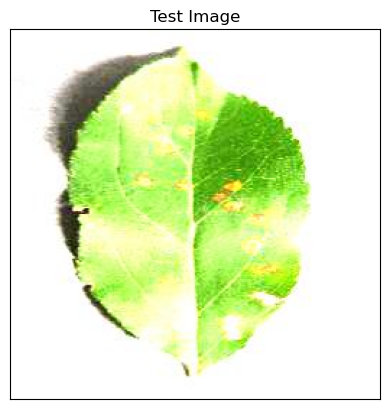

In [13]:
#Test Image Visualization
import cv2
image_path = 'test/test/AppleCedarRust1.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [17]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [19]:
print(predictions)

[[4.10253706e-04 4.14522737e-03 1.40471637e-01 1.30450474e-06
  2.69121514e-03 1.37597221e-04 1.82335361e-06 1.30740236e-05
  4.94826850e-07 1.94900676e-05 7.68745512e-10 9.90967419e-06
  4.57486613e-06 1.20245625e-06 1.90602535e-07 5.81240010e-06
  1.98815484e-03 5.55622876e-07 8.09991777e-01 2.40328125e-04
  4.86726873e-04 8.35540611e-03 1.16847325e-04 5.25066789e-05
  5.43727936e-07 3.86515246e-08 3.53180151e-03 2.76919382e-05
  7.87380995e-05 2.52651633e-03 3.60149425e-05 6.55037875e-05
  2.33788602e-02 7.86546752e-06 1.19883288e-03 8.55616236e-07
  3.33779838e-07 1.89752640e-07]]


In [21]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

18


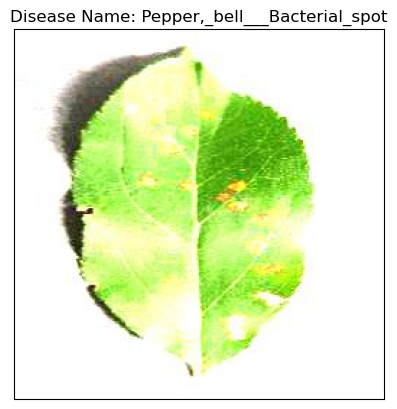

In [24]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()